# Visualisations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mplsoccer import Pitch
import os
import time

from data_reading import get_events
from shared_visuals import draw_pitch
# Global variables
BASE = "https://raw.githubusercontent.com/statsbomb/open-data/master/data"
PITCH_X, PITCH_Y = 120, 80


## Read Data

In [2]:
events_df = get_events(
    target={
    "Competition":"FIFA World Cup",
    "Season": "2022"
    }
    )

c:\Users\luker\OneDrive - University of Bristol\Other\Extra Projects\src\General_visualisations\data_reading.py:149: DtypeWarning: Columns (0: clearance.aerial_won, 1: pass.deflected, 2: block.deflection, 3: foul_committed.advantage, 4: foul_won.advantage, 5: foul_committed.card.name, 6: pass.inswinging, 7: pass.miscommunication, 8: pass.goal_assist, 9: pass.through_ball, 10: shot.one_on_one, 11: dribble.nutmeg, 12: dribble.overrun, 13: 50_50.outcome.name, 14: injury_stoppage.in_chain, 15: dribble.no_touch, 16: clearance.other, 17: pass.outswinging, 18: shot.aerial_won, 19: shot.open_goal, 20: miscontrol.aerial_won, 21: foul_committed.type.name, 22: shot.deflected, 23: pass.cut_back, 24: foul_committed.offensive, 25: block.offensive, 26: shot.saved_to_post, 27: goalkeeper.shot_saved_to_post, 28: foul_committed.penalty, 29: foul_won.penalty, 30: ball_recovery.offensive, 31: pass.straight, 32: pass.no_touch, 33: shot.redirect, 34: goalkeeper.punched_out, 35: bad_behaviour.card.name, 36: 

Event data read from file
Events loaded: (234637, 153)


## Event visualisations

Helper functions

### Event Types

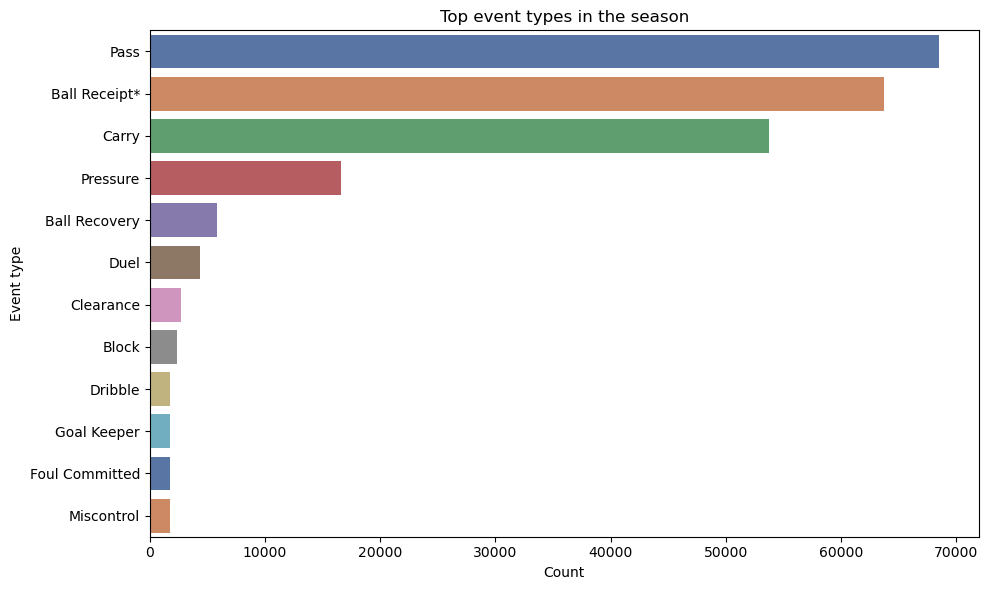

In [10]:

# Plot event type frequencies
plt.figure(figsize=(10, 6))
count_series = events_df["event_type"].value_counts().nlargest(12)
sns.barplot(x=count_series.values, y=count_series.index, hue=count_series.index, palette="deep")
plt.title("Top event types in the season")
plt.xlabel("Count")
plt.ylabel("Event type")
plt.tight_layout()

### Shooting and Passing

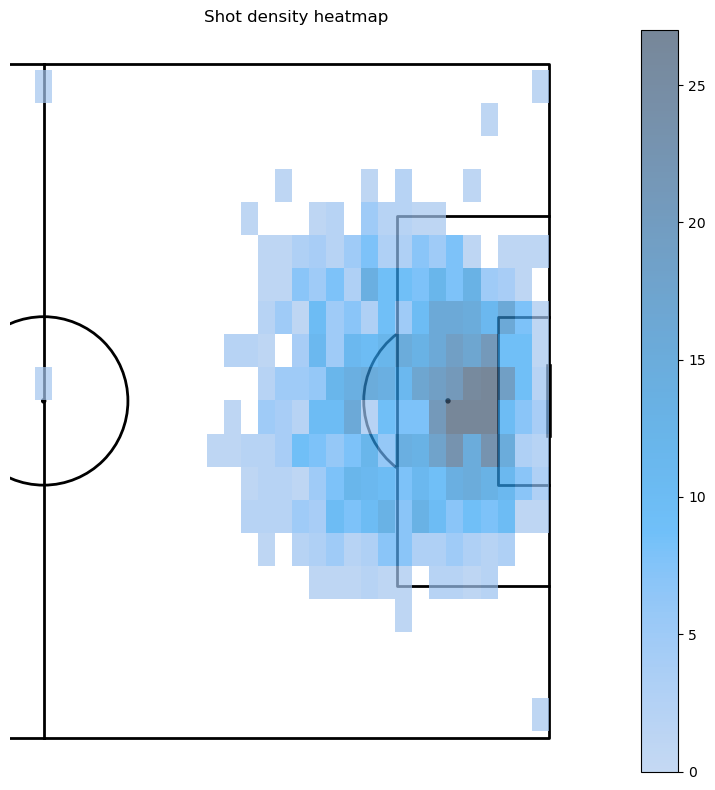

In [11]:
# Get shots events and append xG values
shots = events_df[events_df["event_type"] == "Shot"].copy()
shots = shots.dropna(subset=["x", "y"])
shots["xg"] = shots.get("shot.statsbomb_xg", pd.Series(0, index=shots.index)).fillna(0)

# Heatmap of shot density
fig, ax = plt.subplots(figsize=(12, 8))
draw_pitch(ax, draw_half=True)
sns.histplot(
    data=shots,
    x="x",
    y="y",
    bins=(30, 20),
    pmax=0.9,
    # cmap="cool",
    cbar=True,
    ax=ax,
    alpha=0.7
)
ax.set_title("Shot density heatmap")
plt.tight_layout()

# # Example pass summary
# passes = events_df[events_df["event_type"] == "Pass"].copy()
# pass_summary = (
#     passes.groupby(["player_name", "pass.recipient.name"])
#     .size()
#     .reset_index(name="pass_count")
#     .sort_values("pass_count", ascending=False)
#     .head(10)
# )
# print("Top 10 pass combinations")
# print(pass_summary)
# pass_summary = pass_summary.rename(columns={"pass.recipient.name": "recipient_name"})
# # Create new column for combined player names
# pass_summary["player_combination"] = pass_summary["player_name"] + " -> " + pass_summary["recipient_name"]
# plt.figure(figsize=(10, 6))
# sns.barplot(data=pass_summary, x="pass_count", y="player_combination", hue="pass_count", palette="deep")
# plt.show()